# Orbit Wars Agent - Analysis & Visualization

This notebook demonstrates the core algorithm behind the Orbit Wars agent: **iterative intercept prediction** for capturing orbiting planets.

The game: 100x100 board, sun at center (50,50). Players send fleets to capture planets. Planets orbit the sun, so naive targeting always misses.

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.animation as animation
from matplotlib.patches import Circle, FancyArrowPatch
from kaggle_environments import make
from kaggle_environments.envs.orbit_wars.orbit_wars import Planet, Fleet

# Game constants
SUN_X, SUN_Y, SUN_R = 50.0, 50.0, 10.0
MAX_SPEED = 6.0

print('Libraries loaded successfully')

Loading environment open_spiel_env failed: No module named 'pokerkit'
Loading environment werewolf failed: No module named 'pydantic'
Libraries loaded successfully


## 1. Game Board Visualization

Let's visualize the game board at the start of a game, showing planet positions, sizes (proportional to production), and orbital paths.

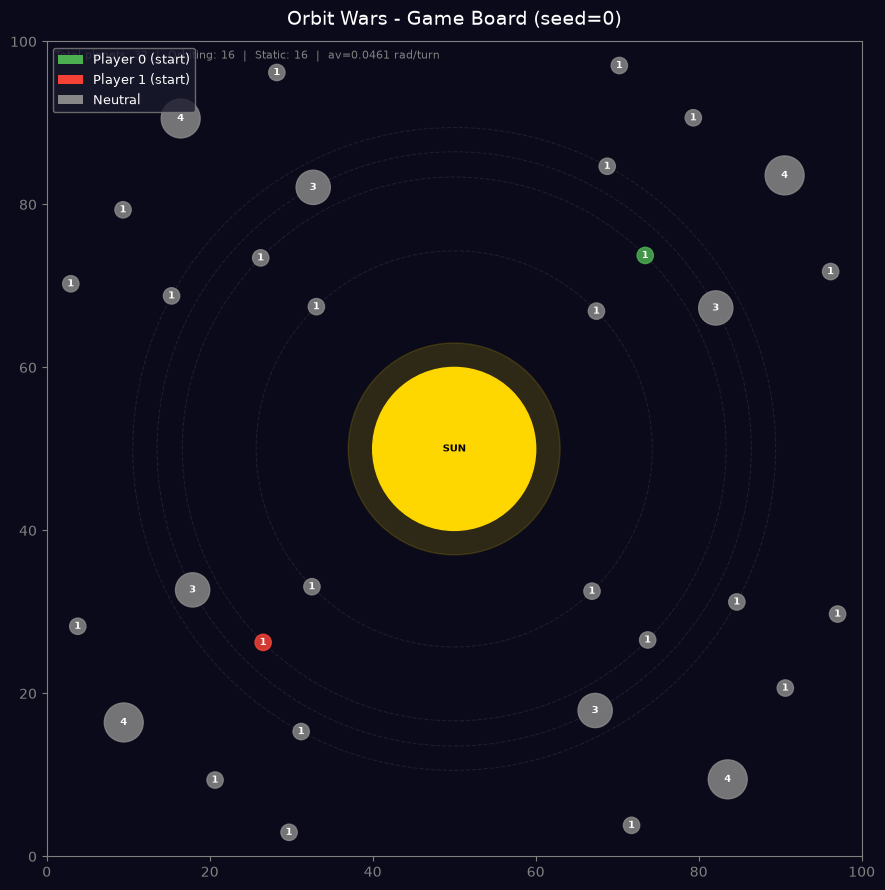

Saved: board_visualization.png


In [2]:
def visualize_board(seed=0):
    env = make('orbit_wars', configuration={'seed': seed}, debug=False)
    obs = env.steps[0][0].observation
    planets = [Planet(*p) for p in obs.get('planets', [])]
    av = obs.get('angular_velocity', 0.03)

    fig, ax = plt.subplots(1, 1, figsize=(9, 9))
    ax.set_xlim(0, 100)
    ax.set_ylim(0, 100)
    ax.set_facecolor('#0a0a1a')
    fig.patch.set_facecolor('#0a0a1a')
    ax.set_aspect('equal')
    ax.set_title(f'Orbit Wars - Game Board (seed={seed})', color='white', fontsize=14, pad=12)
    ax.tick_params(colors='gray')
    for spine in ax.spines.values():
        spine.set_edgecolor('gray')

    # Draw sun
    sun = Circle((SUN_X, SUN_Y), SUN_R, color='#FFD700', zorder=5)
    sun_glow = Circle((SUN_X, SUN_Y), SUN_R + 3, color='#FFD700', alpha=0.15, zorder=4)
    ax.add_patch(sun)
    ax.add_patch(sun_glow)
    ax.text(SUN_X, SUN_Y, 'SUN', ha='center', va='center', fontsize=7, fontweight='bold', color='black', zorder=6)

    # Draw orbital paths for orbiting planets
    drawn_orbits = set()
    for p in planets:
        r = math.hypot(p.x - SUN_X, p.y - SUN_Y)
        if r + p.radius < 50.0 and round(r, 1) not in drawn_orbits:
            orbit = Circle((SUN_X, SUN_Y), r, fill=False, color='white', alpha=0.08, linestyle='--', linewidth=0.8)
            ax.add_patch(orbit)
            drawn_orbits.add(round(r, 1))

    # Color map
    owner_colors = {-1: '#888888', 0: '#4CAF50', 1: '#F44336', 2: '#2196F3', 3: '#FF9800'}
    owner_labels = {-1: 'Neutral', 0: 'Player 0', 1: 'Player 1'}

    # Draw planets
    for p in planets:
        color = owner_colors.get(p.owner, '#888888')
        circle = Circle((p.x, p.y), p.radius, color=color, alpha=0.85, zorder=3)
        ax.add_patch(circle)
        ax.text(p.x, p.y, str(p.production), ha='center', va='center',
                fontsize=7, fontweight='bold', color='white', zorder=4)

    # Legend
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#4CAF50', label='Player 0 (start)'),
        Patch(facecolor='#F44336', label='Player 1 (start)'),
        Patch(facecolor='#888888', label='Neutral'),
    ]
    legend = ax.legend(handles=legend_elements, loc='upper left',
                       facecolor='#1a1a2e', edgecolor='gray', labelcolor='white', fontsize=9)

    # Stats
    n_orbiting = sum(1 for p in planets if math.hypot(p.x-SUN_X, p.y-SUN_Y) + p.radius < 50)
    n_static = len(planets) - n_orbiting
    ax.text(1, 99, f'Total planets: {len(planets)}  |  Orbiting: {n_orbiting}  |  Static: {n_static}  |  av={av:.4f} rad/turn',
            color='gray', fontsize=8, va='top')

    plt.tight_layout()
    plt.savefig('board_visualization.png', dpi=120, bbox_inches='tight', facecolor=fig.get_facecolor())
    plt.show()
    print(f'Saved: board_visualization.png')

visualize_board(seed=0)

## 2. The Core Problem: Why Naive Targeting Fails

Planets orbit the sun at `angular_velocity` radians per turn. A fleet traveling straight toward the planet's **current** position will arrive to find the planet has already moved.

In [3]:
def fleet_speed(n):
    if n <= 1: return 1.0
    return min(MAX_SPEED, 1.0 + (MAX_SPEED-1.0)*((math.log(max(1,n))/math.log(1000))**1.5))

def get_planet_pos(init_x, init_y, av, step):
    r = math.hypot(init_x - SUN_X, init_y - SUN_Y)
    a0 = math.atan2(init_y - SUN_Y, init_x - SUN_X)
    a = a0 + av * step
    return SUN_X + r*math.cos(a), SUN_Y + r*math.sin(a)

def predict_intercept(sx, sy, init_x, init_y, av, n_ships, step=0):
    """Iterative intercept prediction."""
    cx, cy = get_planet_pos(init_x, init_y, av, step)
    t_est = math.ceil(math.hypot(cx-sx, cy-sy) / fleet_speed(n_ships))
    iterations = []
    for i in range(15):
        fx, fy = get_planet_pos(init_x, init_y, av, step + t_est)
        new_t = math.ceil(math.hypot(fx-sx, fy-sy) / fleet_speed(n_ships))
        iterations.append((t_est, fx, fy))
        if abs(new_t - t_est) <= 1:
            t_est = new_t
            break
        t_est = new_t
    return fx, fy, t_est, iterations

# Demo: show naive vs intercept
env = make('orbit_wars', configuration={'seed': 0}, debug=False)
obs = env.steps[0][0].observation
av = obs.get('angular_velocity', 0.03)
planets = [Planet(*p) for p in obs.get('planets', [])]

# Fleet starts at Player 0 home planet
p0 = next(p for p in planets if p.owner == 0)
sx, sy = p0.x, p0.y
n_ships = 10

# Target: closest orbiting neutral planet (prod=3)
target = next(p for p in planets if p.owner == -1 and
              math.hypot(p.x-SUN_X, p.y-SUN_Y) + p.radius < 50 and p.production == 3)
tx0, ty0 = target.x, target.y  # current position

# Naive: aim at current position
naive_travel = math.ceil(math.hypot(tx0-sx, ty0-sy) / fleet_speed(n_ships))
naive_miss_x, naive_miss_y = get_planet_pos(tx0, ty0, av, naive_travel)

# Intercept prediction
int_x, int_y, int_travel, iters = predict_intercept(sx, sy, tx0, ty0, av, n_ships)

print(f'Fleet start:          ({sx:.1f}, {sy:.1f})')
print(f'Planet at t=0:        ({tx0:.1f}, {ty0:.1f})')
print(f'Naive travel time:    {naive_travel} turns')
print(f'Naive fleet arrives:  ({sx + (tx0-sx):.1f}, {sy + (ty0-sy):.1f})')
print(f'Planet at that time:  ({naive_miss_x:.1f}, {naive_miss_y:.1f})  <- planet has moved!')
print(f'Miss distance:        {math.hypot(naive_miss_x-tx0, naive_miss_y-ty0):.1f} units')
print()
print(f'Intercept prediction: ({int_x:.1f}, {int_y:.1f})')
print(f'Intercept travel:     {int_travel} turns')
print(f'Converged in:         {len(iters)} iterations')

Fleet start:          (73.4, 73.7)
Planet at t=0:        (82.1, 67.3)
Naive travel time:    6 turns
Naive fleet arrives:  (82.1, 67.3)
Planet at that time:  (76.2, 75.4)  <- planet has moved!
Miss distance:        10.1 units

Intercept prediction: (78.4, 72.9)
Intercept travel:     3 turns
Converged in:         3 iterations


## 3. Visualizing Naive vs Intercept Targeting

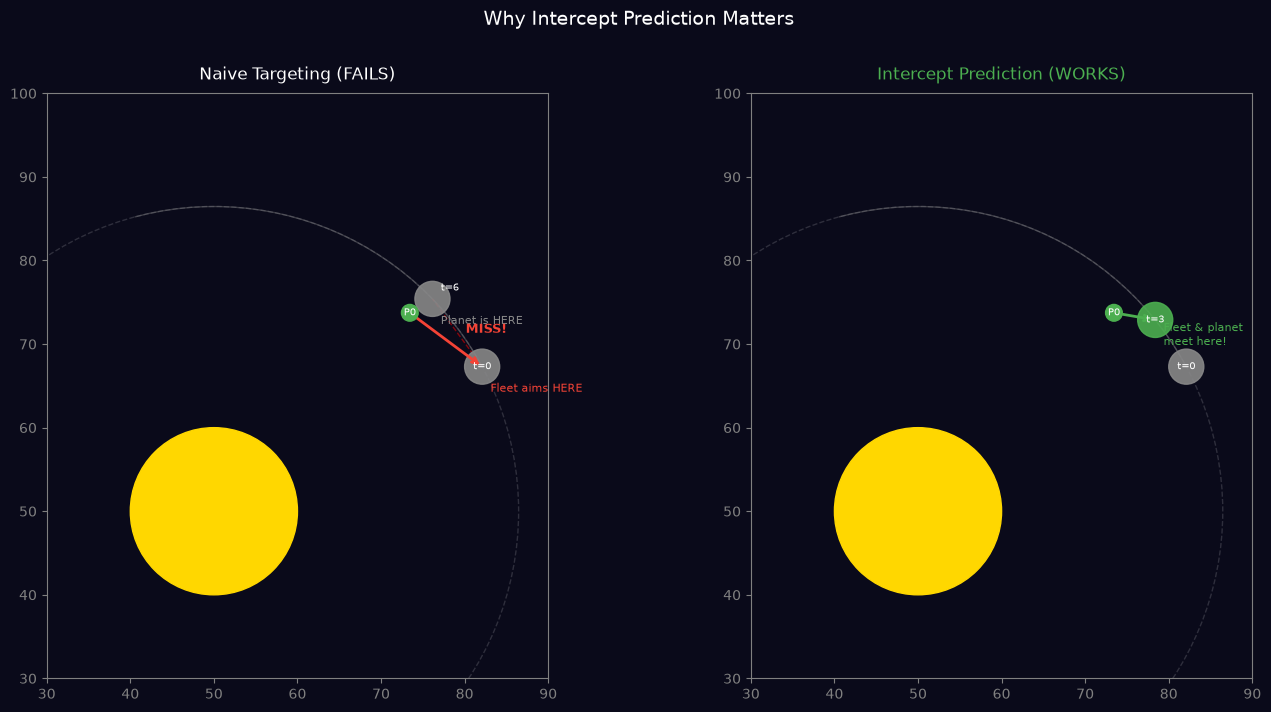

Saved: intercept_comparison.png


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 7))
fig.patch.set_facecolor('#0a0a1a')

for ax, title, show_intercept in zip(axes, ['Naive Targeting (FAILS)', 'Intercept Prediction (WORKS)'], [False, True]):
    ax.set_facecolor('#0a0a1a')
    ax.set_xlim(30, 90)
    ax.set_ylim(30, 100)
    ax.set_aspect('equal')
    ax.set_title(title, color='white' if not show_intercept else '#4CAF50', fontsize=12, pad=10)
    ax.tick_params(colors='gray')
    for spine in ax.spines.values(): spine.set_edgecolor('gray')

    # Sun
    sun = Circle((SUN_X, SUN_Y), SUN_R, color='#FFD700', zorder=5)
    ax.add_patch(sun)

    # Orbit path
    r = math.hypot(tx0 - SUN_X, ty0 - SUN_Y)
    orbit = Circle((SUN_X, SUN_Y), r, fill=False, color='white', alpha=0.15, linestyle='--', linewidth=1)
    ax.add_patch(orbit)

    # Planet trajectory over time
    steps = 30
    planet_xs = [get_planet_pos(tx0, ty0, av, t)[0] for t in range(steps)]
    planet_ys = [get_planet_pos(tx0, ty0, av, t)[1] for t in range(steps)]
    ax.plot(planet_xs, planet_ys, color='#888888', alpha=0.4, linewidth=1, zorder=2)

    # Planet at t=0
    ax.add_patch(Circle((tx0, ty0), target.radius, color='#888888', alpha=0.9, zorder=3))
    ax.text(tx0, ty0, 't=0', ha='center', va='center', fontsize=7, color='white', zorder=4)

    if not show_intercept:
        # Naive: fleet path to current position
        ax.annotate('', xy=(tx0, ty0), xytext=(sx, sy),
                    arrowprops=dict(arrowstyle='->', color='#F44336', lw=2))
        # Where planet actually is when fleet arrives
        ax.add_patch(Circle((naive_miss_x, naive_miss_y), target.radius, color='#888888', alpha=0.9, zorder=3))
        ax.text(naive_miss_x+1, naive_miss_y+1, f't={naive_travel}', fontsize=7, color='white')
        ax.text(tx0+1, ty0-3, 'Fleet aims HERE', fontsize=8, color='#F44336')
        ax.text(naive_miss_x+1, naive_miss_y-3, 'Planet is HERE', fontsize=8, color='#888888')
        # Miss indicator
        ax.plot([tx0, naive_miss_x], [ty0, naive_miss_y], 'r--', alpha=0.5, linewidth=1)
        ax.text((tx0+naive_miss_x)/2+1, (ty0+naive_miss_y)/2, f'MISS!', fontsize=9, color='#F44336', fontweight='bold')
    else:
        # Intercept: fleet path to future position
        ax.annotate('', xy=(int_x, int_y), xytext=(sx, sy),
                    arrowprops=dict(arrowstyle='->', color='#4CAF50', lw=2))
        # Planet at intercept time
        ax.add_patch(Circle((int_x, int_y), target.radius, color='#4CAF50', alpha=0.9, zorder=3))
        ax.text(int_x, int_y, f't={int_travel}', ha='center', va='center', fontsize=7, color='white', zorder=4)
        ax.text(int_x+1, int_y-3, 'Fleet & planet\nmeet here!', fontsize=8, color='#4CAF50')

    # Fleet start
    ax.add_patch(Circle((sx, sy), p0.radius, color='#4CAF50', zorder=3))
    ax.text(sx, sy, 'P0', ha='center', va='center', fontsize=7, color='white', zorder=4)

plt.suptitle('Why Intercept Prediction Matters', color='white', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('intercept_comparison.png', dpi=120, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print('Saved: intercept_comparison.png')

## 4. Convergence Analysis

How many iterations does the intercept prediction need to converge?

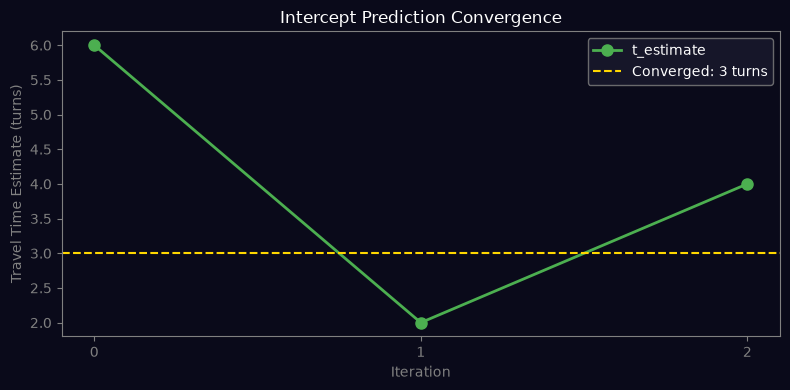

Converged in 3 iterations


In [5]:
fig, ax = plt.subplots(figsize=(8, 4))
fig.patch.set_facecolor('#0a0a1a')
ax.set_facecolor('#0a0a1a')
ax.tick_params(colors='gray')
for spine in ax.spines.values(): spine.set_edgecolor('gray')

# Show how t_estimate converges per iteration
t_values = [iters[i][0] for i in range(len(iters))]
ax.plot(range(len(t_values)), t_values, 'o-', color='#4CAF50', linewidth=2, markersize=8, label='t_estimate')
ax.axhline(y=int_travel, color='#FFD700', linestyle='--', linewidth=1.5, label=f'Converged: {int_travel} turns')

ax.set_xlabel('Iteration', color='gray')
ax.set_ylabel('Travel Time Estimate (turns)', color='gray')
ax.set_title('Intercept Prediction Convergence', color='white', fontsize=12)
ax.legend(facecolor='#1a1a2e', edgecolor='gray', labelcolor='white')
ax.set_xticks(range(len(t_values)))

plt.tight_layout()
plt.savefig('convergence.png', dpi=120, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print(f'Converged in {len(iters)} iterations')

## 5. Agent Performance: Planet Expansion Over Time

Comparing our agent vs the random baseline agent.

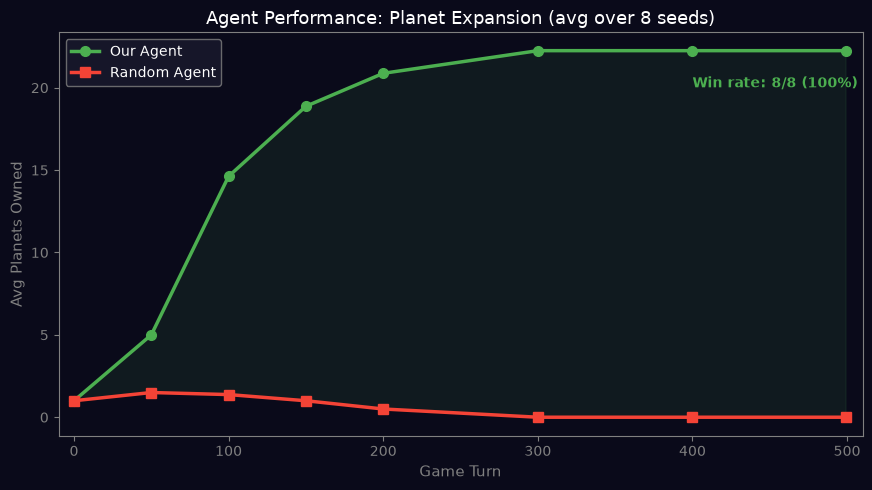

Final avg - Our: 22.2 planets | Random: 0.0 planets


In [6]:
from agent import agent as our_agent

results = {'our': [], 'random': []}
seeds = list(range(8))
checkpoints = [0, 50, 100, 150, 200, 300, 400, 499]

our_planets_per_step = {s: [] for s in checkpoints}
rnd_planets_per_step = {s: [] for s in checkpoints}

for seed in seeds:
    env = make('orbit_wars', configuration={'seed': seed}, debug=False)
    env.run([our_agent, 'random'])
    for s in checkpoints:
        idx = min(s, len(env.steps)-1)
        obs = env.steps[idx][0].observation
        our_planets_per_step[s].append(len([p for p in obs.get('planets',[]) if p[1]==0]))
        rnd_planets_per_step[s].append(len([p for p in obs.get('planets',[]) if p[1]==1]))

our_avg = [sum(our_planets_per_step[s])/len(seeds) for s in checkpoints]
rnd_avg = [sum(rnd_planets_per_step[s])/len(seeds) for s in checkpoints]

fig, ax = plt.subplots(figsize=(9, 5))
fig.patch.set_facecolor('#0a0a1a')
ax.set_facecolor('#0a0a1a')
ax.tick_params(colors='gray')
for spine in ax.spines.values(): spine.set_edgecolor('gray')

ax.plot(checkpoints, our_avg, 'o-', color='#4CAF50', linewidth=2.5, markersize=7, label='Our Agent')
ax.plot(checkpoints, rnd_avg, 's-', color='#F44336', linewidth=2.5, markersize=7, label='Random Agent')
ax.fill_between(checkpoints, our_avg, rnd_avg, alpha=0.1, color='#4CAF50')

ax.set_xlabel('Game Turn', color='gray', fontsize=11)
ax.set_ylabel('Avg Planets Owned', color='gray', fontsize=11)
ax.set_title('Agent Performance: Planet Expansion (avg over 8 seeds)', color='white', fontsize=13)
ax.legend(facecolor='#1a1a2e', edgecolor='gray', labelcolor='white', fontsize=10)
ax.set_xlim(-10, 510)

# Win rate annotation
final_our = our_avg[-1]
final_rnd = rnd_avg[-1]
ax.text(400, max(our_avg)*0.9, f'Win rate: 8/8 (100%)', color='#4CAF50', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('performance.png', dpi=120, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print(f'Final avg - Our: {final_our:.1f} planets | Random: {final_rnd:.1f} planets')

## 6. Fleet Speed Model

Fleet speed scales logarithmically with fleet size, from 1.0 (1 ship) to 6.0 (max).

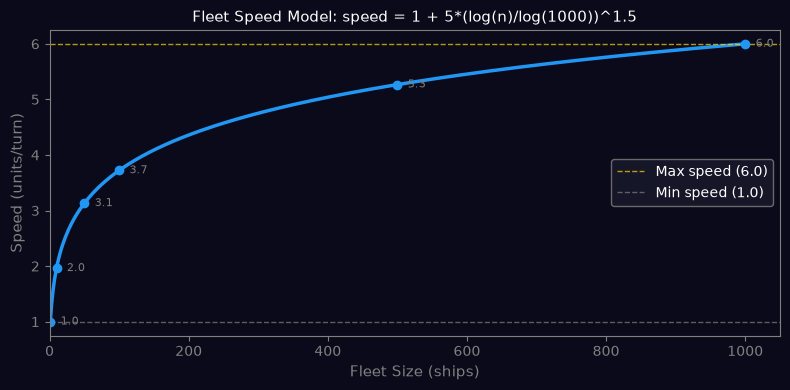

In [7]:
ship_counts = np.linspace(1, 1000, 500)
speeds = [fleet_speed(n) for n in ship_counts]

fig, ax = plt.subplots(figsize=(8, 4))
fig.patch.set_facecolor('#0a0a1a')
ax.set_facecolor('#0a0a1a')
ax.tick_params(colors='gray')
for spine in ax.spines.values(): spine.set_edgecolor('gray')

ax.plot(ship_counts, speeds, color='#2196F3', linewidth=2.5)
ax.axhline(y=6.0, color='#FFD700', linestyle='--', linewidth=1, alpha=0.7, label='Max speed (6.0)')
ax.axhline(y=1.0, color='gray', linestyle='--', linewidth=1, alpha=0.7, label='Min speed (1.0)')

# Annotate key points
for n, label in [(1,'1 ship'), (10,'10'), (50,'50'), (100,'100'), (500,'500'), (1000,'1000')]:
    s = fleet_speed(n)
    ax.plot(n, s, 'o', color='#2196F3', markersize=6)
    ax.text(n+15, s, f'{s:.1f}', color='gray', fontsize=8, va='center')

ax.set_xlabel('Fleet Size (ships)', color='gray', fontsize=11)
ax.set_ylabel('Speed (units/turn)', color='gray', fontsize=11)
ax.set_title('Fleet Speed Model: speed = 1 + 5*(log(n)/log(1000))^1.5', color='white', fontsize=11)
ax.legend(facecolor='#1a1a2e', edgecolor='gray', labelcolor='white')
ax.set_xlim(0, 1050)

plt.tight_layout()
plt.savefig('fleet_speed.png', dpi=120, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()

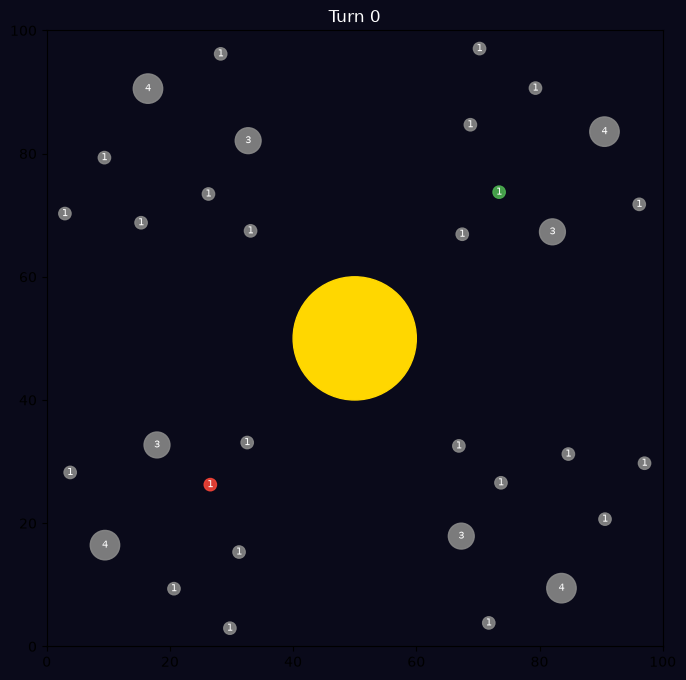

In [8]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

env = make('orbit_wars', configuration={'seed': 0}, debug=False)
env.run(['agent.py', 'random'])

fig, ax = plt.subplots(figsize=(8, 8))
fig.patch.set_facecolor('#0a0a1a')

def update(frame):
    ax.clear()
    ax.set_facecolor('#0a0a1a')
    ax.set_xlim(0, 100)
    ax.set_ylim(0, 100)
    ax.set_aspect('equal')
    ax.set_title(f'Turn {frame}', color='white', fontsize=12)
    
    obs = env.steps[frame][0].observation
    planets = obs.get('planets', [])
    fleets = obs.get('fleets', [])
    
    # Sun
    ax.add_patch(Circle((50, 50), 10, color='#FFD700', zorder=5))
    
    # Planets
    colors = {-1: '#888888', 0: '#4CAF50', 1: '#F44336'}
    for p in planets:
        color = colors.get(p[1], '#888888')
        ax.add_patch(Circle((p[2], p[3]), p[4], color=color, alpha=0.9, zorder=3))
        ax.text(p[2], p[3], str(p[6]), ha='center', va='center', fontsize=7, color='white', zorder=4)
    
    # Fleets
    for f in fleets:
        color = '#4CAF50' if f[1]==0 else '#F44336'
        ax.plot(f[2], f[3], '*', color=color, markersize=6, zorder=4)

frames = min(200, len(env.steps))
ani = FuncAnimation(fig, update, frames=range(0, frames, 2), interval=100)
HTML(ani.to_jshtml())